# Semantic Drift Explorer — Reddit 2015–2023

This notebook explores how word meanings on Reddit shifted between 2015 and 2023.

**Method:** a separate Word2Vec embedding was trained on each year's cleaned Reddit comments, then every year's embedding space was rotated onto a shared 2015-anchored coordinate system using orthogonal Procrustes alignment (`scripts/align_embeddings.py`). Only once embeddings live in the same coordinate system can a word's vector be compared across years — drift is measured as cosine distance between a word's aligned vector in different years (`scripts/compute_drift.py`).

## Top drifted words

The table below ranks words by **cumulative drift**: cosine distance between their 2015 vector and their 2023 vector, after alignment. Higher values mean the word moved further from its 2015 meaning. This ranking is already filtered (`top_drifted_words.json`) to drop noisy short tokens and acronyms — see `data/top_drifted_words_unfiltered.json` for the raw version.

In [1]:
import json
from pathlib import Path

import pandas as pd

DATA_DIR = Path("..") / "data"

with open(DATA_DIR / "top_drifted_words.json", "r", encoding="utf-8") as f:
    top_drifted = json.load(f)

with open(DATA_DIR / "drift_results.json", "r", encoding="utf-8") as f:
    drift_results = json.load(f)

top_30 = pd.DataFrame(top_drifted[:30], columns=["word", "cumulative_drift"])
top_30.index = top_30.index + 1
top_30.index.name = "rank"
top_30

,word,cumulative_drift
rank,,
1,bold,0.787941
2,specials,0.756401
3,contest,0.743330
4,hentai,0.726347
5,targeting,0.726307
6,spotting,0.719738
7,universal,0.716945
8,strictly,0.712013
9,holder,0.709548


## Neighbor shift viewer

For a single word, this shows its top-5 nearest neighbors *within each year's own embedding space*. Watching the neighbor list change year over year is often more intuitive than a single drift number — it shows *what* the word's meaning shifted towards.

Change `WORD` below to explore a different word (it must be in the shared vocabulary across all 9 years).

In [2]:
WORD = "cough"

years = [str(y) for y in range(2015, 2024)]
neighbor_table = {
    year: [n[0] for n in drift_results[WORD]["neighbors"][year][:5]]
    for year in years
}

neighbor_df = pd.DataFrame(neighbor_table)
neighbor_df.index = neighbor_df.index + 1
neighbor_df.index.name = "rank"
neighbor_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023
rank,,,,,,,,,
1,autocorrect,hangovers,excessively,strawberry,whooping,tornado,fever,congestion,aches
2,bled,woooo,sinus,greens,syrup,peaches,depressive,fever,vomiting
3,swallowing,snorting,squish,mango,sneeze,scrambled,migraine,runny,cravings
4,fanboys,rejoice,stinks,bleh,soggy,noodles,sips,sinus,constipation
5,cramps,fragrance,valium,hazel,slimy,tbsp,cramps,aches,numb


## Drift timeline chart

A rising line means the word kept moving further from its 2015 meaning each year. A flat line means it settled into a new meaning early and stayed there. A line that dips and rises again suggests unstable usage rather than steady drift in one direction.

Matplotlib is building the font cache; this may take a moment.


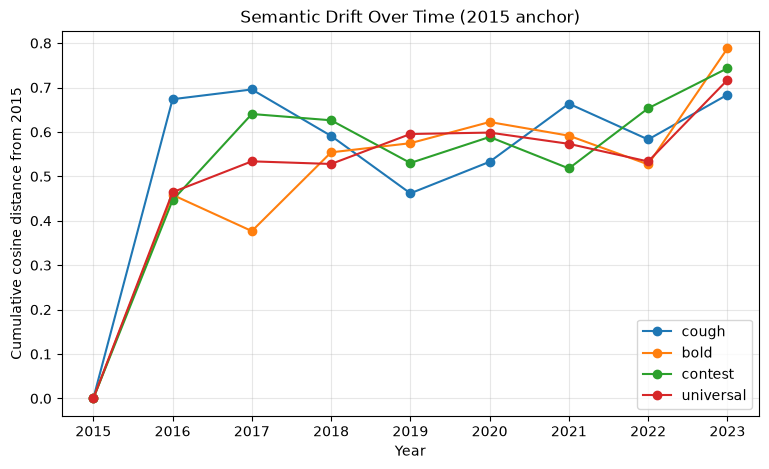

In [3]:
import matplotlib.pyplot as plt

words_to_plot = ["cough", "bold", "contest", "universal"]
years_int = list(range(2015, 2024))

plt.figure(figsize=(9, 5))
for word in words_to_plot:
    drift_by_year = [drift_results[word]["cumulative_drift"][str(y)] for y in years_int]
    plt.plot(years_int, drift_by_year, marker="o", label=word)

plt.xlabel("Year")
plt.ylabel("Cumulative cosine distance from 2015")
plt.title("Semantic Drift Over Time (2015 anchor)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Neighbor overlap analysis (Jaccard similarity)

Cumulative cosine distance tells you a word's vector moved, but not whether its *meaning* changed — a word can drift a little in every direction without ever changing what it's "about". A sharper test: compare the word's nearest-neighbor set in 2015 against its nearest-neighbor set in 2023 using Jaccard similarity (`|intersection| / |union|`). A **low** Jaccard score means the word is now surrounded by almost entirely different words — much stronger evidence of real meaning change than cosine distance alone.

In [4]:
def neighbor_set(word, year):
    return set(n[0] for n in drift_results[word]["neighbors"][str(year)])


def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


rows = []
for word, drift in top_drifted[:30]:
    set_2015 = neighbor_set(word, 2015)
    set_2023 = neighbor_set(word, 2023)
    rows.append({
        "word": word,
        "cumulative_drift": drift,
        "jaccard_2015_2023": jaccard(set_2015, set_2023),
    })

jaccard_df = (
    pd.DataFrame(rows)
    .sort_values("jaccard_2015_2023")
    .head(15)
    .reset_index(drop=True)
)
jaccard_df

,word,cumulative_drift,jaccard_2015_2023
0,bold,0.787941,0.0
1,specials,0.756401,0.0
2,contest,0.743330,0.0
3,hentai,0.726347,0.0
4,targeting,0.726307,0.0
5,spotting,0.719738,0.0
6,universal,0.716945,0.0
7,strictly,0.712013,0.0
8,holder,0.709548,0.0
9,pinned,0.707123,0.0


## Find your story

A hand-picked set of words to look at closely: their 2015 neighbors vs. their 2023 neighbors, side by side. Use the markdown cell after each table to jot down your interpretation — is this a real meaning shift, a cultural/event-driven shift (e.g. COVID), or just noise?

In [5]:
def neighbor_comparison(word, k=5):
    rows_2015 = [n[0] for n in drift_results[word]["neighbors"]["2015"][:k]]
    rows_2023 = [n[0] for n in drift_results[word]["neighbors"]["2023"][:k]]
    df = pd.DataFrame({"2015": rows_2015, "2023": rows_2023})
    df.index = df.index + 1
    df.index.name = "rank"
    return df

In [6]:
neighbor_comparison("cough")

,2015,2023
rank,,
1,autocorrect,aches
2,bled,vomiting
3,swallowing,cravings
4,fanboys,constipation
5,cramps,numb


**Interpretation — "cough":** _Write your thoughts here._

In [7]:
neighbor_comparison("mask")

,2015,2023
rank,,
1,majoras,masks
2,sharpie,dyed
3,wig,goggles
4,paws,brushed
5,crotch,sprayed


**Interpretation — "mask":** _Write your thoughts here._

In [8]:
neighbor_comparison("bold")

,2015,2023
rank,,
1,ralts,proposition
2,timid,justifies
3,dratini,alignment
4,froakie,glaring
5,feebas,ludicrous


**Interpretation — "bold":** _Write your thoughts here._

In [9]:
neighbor_comparison("pinned")

,2015,2023
rank,,
1,rook,megathread
2,bigs,sticked
3,jammed,weekly
4,rushes,stickied
5,elbows,sticky


**Interpretation — "pinned":** _Write your thoughts here._

In [10]:
neighbor_comparison("contest")

,2015,2023
rank,,
1,prizes,ultrakill
2,giveaways,artworks
3,giveaway,alldayfucknsfw
4,winners,mode
5,grats,ratemynudebody


**Interpretation — "contest":** _Write your thoughts here._

In [11]:
neighbor_comparison("grand")

,2015,2023
rank,,
1,budapest,stannis
2,rapids,bran
3,boyhood,raven
4,baltimore,gimli
5,canyon,olenna


**Interpretation — "grand":** _Write your thoughts here._

In [12]:
neighbor_comparison("holder")

,2015,2023
rank,,
1,debit,copyright
2,wallets,agreeing
3,brokerage,onlyfanspromotion
4,repairs,permission
5,groceries,specials


**Interpretation — "holder":** _Write your thoughts here._